# **Crop Yield Prediction**

### **Major Project – Theme 8: Agriculture**

**Name:** Sanjay S  
**Domain:** Artificial Intelligence  
**Batch:** July 2026

**STEP 1 — Import Libraries & Load Dataset**

The crop yield dataset is loaded and examined to understand its structure,
dimensions, column names, data types, and basic statistical characteristics.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [63]:
df = pd.read_csv('/content/yield_df.csv')

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nFirst 10 Rows:")
display(df.head(10))

print("\nStatistical Summary:")
display(df.describe(include='all'))

Dataset loaded successfully!
Dataset Shape: (28242, 8)

Column Names:
['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB

First 10 Rows:


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37
5,5,Albania,Wheat,1990,30197,1485.0,121.0,16.37
6,6,Albania,Maize,1991,29068,1485.0,121.0,15.36
7,7,Albania,Potatoes,1991,77818,1485.0,121.0,15.36
8,8,Albania,"Rice, paddy",1991,28538,1485.0,121.0,15.36
9,9,Albania,Sorghum,1991,6667,1485.0,121.0,15.36



Statistical Summary:


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242,28242,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
unique,NaN,101,10,NaN,NaN,NaN,NaN,NaN
top,NaN,India,Potatoes,NaN,NaN,NaN,NaN,NaN
freq,NaN,4048,4276,NaN,NaN,NaN,NaN,NaN
mean,14120.500000,NaN,NaN,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,NaN,NaN,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,NaN,NaN,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,NaN,NaN,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,NaN,NaN,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,NaN,NaN,2008.000000,104676.750000,1668.00000,48687.880000,26.000000


**STEP 2 — Check Missing Values**

In this step, the dataset is checked for missing values and basic structural information is reviewed to ensure that the data is suitable for further analysis.

In [64]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


In [65]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [66]:
print("Dataset Shape:", df.shape)
print("\nDataset Information:")
df.info()

Dataset Shape: (28242, 8)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB


In [67]:
df = df.drop(columns=['Unnamed: 0'])
print("Column 'Unnamed: 0' removed.")
print("Dataset Shape after removing index column:", df.shape)
print("\nRemaining Columns:")
print(df.columns.tolist())

Column 'Unnamed: 0' removed.
Dataset Shape after removing index column: (28242, 7)

Remaining Columns:
['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


In [68]:
display(df.head())
print("\nFinal Dataset Shape:", df.shape)

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37



Final Dataset Shape: (28242, 7)


**STEP 3 — Check & Handle Duplicates**

Duplicate records are identified to prevent repeated observations from affecting the analysis and machine learning models. Any duplicate rows found are removed from the dataset.

In [69]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 2310


In [70]:
if duplicate_count > 0:
    print("Duplicate rows found:")
    display(df[df.duplicated(keep=False)].head(20))
else:
    print("No duplicate rows found.")

Duplicate rows found:


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
2082,Bangladesh,Maize,1990,10015,2666.0,1266.0,25.98
2083,Bangladesh,Maize,1990,10015,2666.0,1266.0,25.98
2084,Bangladesh,Potatoes,1990,91410,2666.0,1266.0,25.98
2085,Bangladesh,Potatoes,1990,91410,2666.0,1266.0,25.98
2086,Bangladesh,"Rice, paddy",1990,25661,2666.0,1266.0,25.98
2087,Bangladesh,"Rice, paddy",1990,25661,2666.0,1266.0,25.98
2088,Bangladesh,Sorghum,1990,8103,2666.0,1266.0,25.98
2089,Bangladesh,Sorghum,1990,8103,2666.0,1266.0,25.98
2090,Bangladesh,Sweet potatoes,1990,98316,2666.0,1266.0,25.98
2091,Bangladesh,Sweet potatoes,1990,98316,2666.0,1266.0,25.98


STEP 3.1 — Remove Exact Duplicates

In [71]:
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]
print("Rows before removing duplicates:", before)
print("Duplicate rows removed:", before - after)
print("Rows after removing duplicates:", after)
print("Dataset shape after duplicate removal:", df.shape)

Rows before removing duplicates: 28242
Duplicate rows removed: 2310
Rows after removing duplicates: 25932
Dataset shape after duplicate removal: (25932, 7)


In [72]:
print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


STEP 3.2 — Check Numerical Ranges

In [73]:
print("Year range:", df['Year'].min(), "to", df['Year'].max())
print("Yield range:", df['hg/ha_yield'].min(), "to", df['hg/ha_yield'].max())
print("Rainfall range:", df['average_rain_fall_mm_per_year'].min(), "to", df['average_rain_fall_mm_per_year'].max())
print("Pesticides range:", df['pesticides_tonnes'].min(), "to", df['pesticides_tonnes'].max())
print("Temperature range:", df['avg_temp'].min(), "to", df['avg_temp'].max())

Year range: 1990 to 2013
Yield range: 50 to 501412
Rainfall range: 51.0 to 3240.0
Pesticides range: 0.04 to 367778.0
Temperature range: 1.3 to 30.65


In [74]:
print("Year <= 0:", (df['Year'] <= 0).sum())
print("Yield <= 0:", (df['hg/ha_yield'] <= 0).sum())
print("Rainfall <= 0:", (df['average_rain_fall_mm_per_year'] <= 0).sum())
print("Pesticides < 0:", (df['pesticides_tonnes'] < 0).sum())
print("Temperature <= 0:", (df['avg_temp'] <= 0).sum())

Year <= 0: 0
Yield <= 0: 0
Rainfall <= 0: 0
Pesticides < 0: 0
Temperature <= 0: 0


STEP 3.3 — Check Categorical Values

In [75]:
print("Number of unique areas:", df['Area'].nunique())
print("Number of unique crops:", df['Item'].nunique())
print("\nAreas:")
print(df['Area'].unique())
print("\nCrops:")
print(df['Item'].unique())

Number of unique areas: 101
Number of unique crops: 10

Areas:
['Albania' 'Algeria' 'Angola' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Belarus' 'Belgium'
 'Botswana' 'Brazil' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cameroon'
 'Canada' 'Central African Republic' 'Chile' 'Colombia' 'Croatia'
 'Denmark' 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Eritrea'
 'Estonia' 'Finland' 'France' 'Germany' 'Ghana' 'Greece' 'Guatemala'
 'Guinea' 'Guyana' 'Haiti' 'Honduras' 'Hungary' 'India' 'Indonesia' 'Iraq'
 'Ireland' 'Italy' 'Jamaica' 'Japan' 'Kazakhstan' 'Kenya' 'Latvia'
 'Lebanon' 'Lesotho' 'Libya' 'Lithuania' 'Madagascar' 'Malawi' 'Malaysia'
 'Mali' 'Mauritania' 'Mauritius' 'Mexico' 'Montenegro' 'Morocco'
 'Mozambique' 'Namibia' 'Nepal' 'Netherlands' 'New Zealand' 'Nicaragua'
 'Niger' 'Norway' 'Pakistan' 'Papua New Guinea' 'Peru' 'Poland' 'Portugal'
 'Qatar' 'Romania' 'Rwanda' 'Saudi Arabia' 'Senegal' 'Slovenia'
 'South Africa' 'Spain' 'Sr

In [76]:
print("Empty Area values:", (df['Area'].astype(str).str.strip() == '').sum())
print("Empty Item values:", (df['Item'].astype(str).str.strip() == '').sum())

Empty Area values: 0
Empty Item values: 0


**STEP 4 — Outlier Analysis**

Outlier analysis is performed using boxplots and the IQR method to identify
unusual observations in the numerical variables.

4.1 — Boxplots

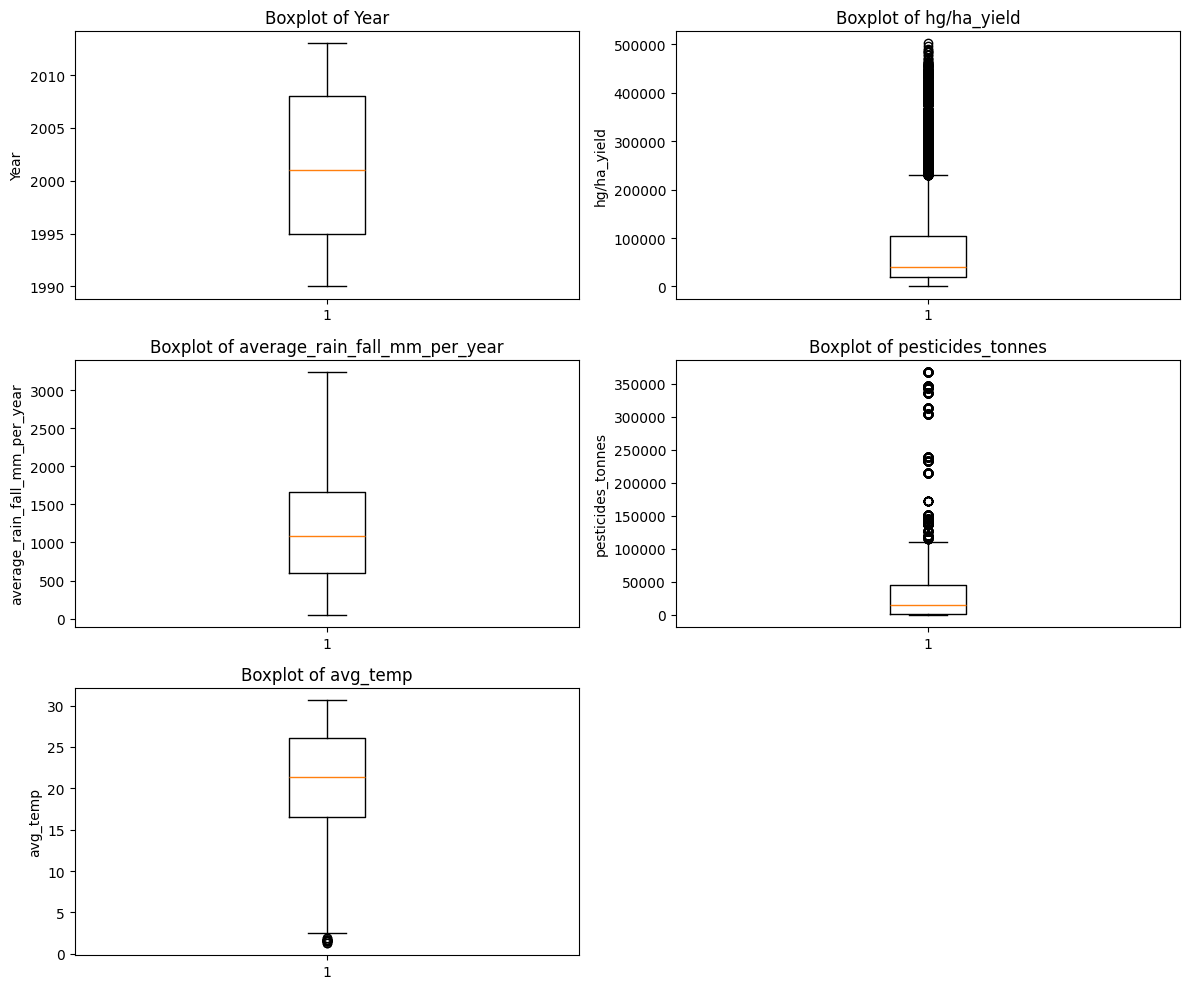

In [77]:
numerical_columns = [
    'Year',
    'hg/ha_yield',
    'average_rain_fall_mm_per_year',
    'pesticides_tonnes',
    'avg_temp'
]

plt.figure(figsize=(12, 10))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(3, 2, i)
    plt.boxplot(df[column])
    plt.title(f'Boxplot of {column}')
    plt.ylabel(column)

plt.tight_layout()
plt.show()

4.2 — Calculate Outliers Using IQR

In [78]:
for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"{column}: {len(outliers)} outliers")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print()

Year: 0 outliers
Lower bound: 1975.50
Upper bound: 2027.50

hg/ha_yield: 1918 outliers
Lower bound: -106262.00
Upper bound: 230426.00

average_rain_fall_mm_per_year: 0 outliers
Lower bound: -1019.50
Upper bound: 3280.50

pesticides_tonnes: 1262 outliers
Lower bound: -64437.50
Upper bound: 111654.50

avg_temp: 16 outliers
Lower bound: 2.36
Upper bound: 40.28



**STEP 5 — Basic Statistical Analysis**

Basic statistical analysis is performed to understand the distribution of crop yield and its relationship with crop type, geographical area, and year.

5.1 Statistical Summary

In [79]:
numerical_columns = [
    'Year',
    'hg/ha_yield',
    'average_rain_fall_mm_per_year',
    'pesticides_tonnes',
    'avg_temp'
]

df[numerical_columns].describe()

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000
mean,2001.556455,76978.132925,1146.836688,34782.573241,20.422251
std,7.055924,84647.605552,717.391098,57228.568244,6.439402
min,1990.000000,50.000000,51.000000,0.040000,1.300000
25%,1995.000000,19996.000000,593.000000,1597.000000,16.580000
50%,2001.000000,39530.000000,1083.000000,15373.000000,21.420000
75%,2008.000000,104168.000000,1668.000000,45620.000000,26.060000
max,2013.000000,501412.000000,3240.000000,367778.000000,30.650000


5.2 Average Yield by Crop

In [80]:
crop_yield = df.groupby('Item')['hg/ha_yield'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).sort_values('mean', ascending=False)

crop_yield

,count,mean,median,min,max
Item,,,,,
Potatoes,3956,198665.725228,180322.5,8406,501412
Cassava,1889,145649.692430,125305.0,11778,385818
Sweet potatoes,2593,119656.515619,99940.0,8799,400000
Yams,774,112105.633075,92593.0,11475,250000
Plantains and others,556,106041.320144,89860.5,21350,418505
"Rice, paddy",3091,41296.028470,36408.0,2034,103895
Maize,3824,37139.320345,25557.0,849,207556
Wheat,3539,30125.681266,25296.0,1706,99387
Sorghum,2770,19099.774729,13548.0,578,206000


5.3 Average Yield by Area

In [81]:
area_yield = df.groupby('Area')['hg/ha_yield'].mean().sort_values(
    ascending=False
)

area_yield.head(20)

,hg/ha_yield
Area,
United Kingdom,240956.478261
Belgium,216468.461538
Denmark,214033.020000
Netherlands,204151.202899
Ireland,197913.695652
New Zealand,191931.826087
Sweden,187405.500000
Bahrain,153237.551724
Norway,146115.326087


5.4 Average Yield by Year

In [82]:
year_yield = df.groupby('Year')['hg/ha_yield'].mean()
year_yield

,hg/ha_yield
Year,
1990,66722.149577
1991,66496.037629
1992,66934.412966
1993,67568.484956
1994,68371.559353
1995,69462.682905
1996,69898.326494
1997,71120.525561
1998,71450.576682


**STEP 6 — Exploratory Data Analysis**

Exploratory Data Analysis is performed using visualizations to investigate relationships between crop yield and important factors such as crop type, area, rainfall, pesticide usage, temperature, and year.

6.1 Crop Type vs Yield

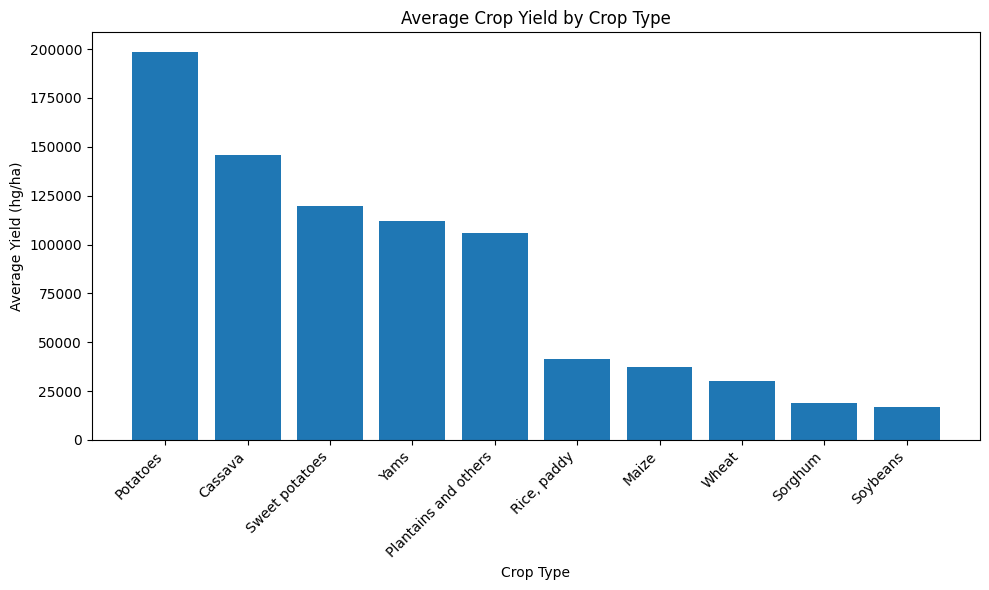

In [83]:
crop_yield_mean = df.groupby('Item')['hg/ha_yield'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(crop_yield_mean.index, crop_yield_mean.values)
plt.xlabel('Crop Type')
plt.ylabel('Average Yield (hg/ha)')
plt.title('Average Crop Yield by Crop Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

6.2 Year vs Average Crop Yield

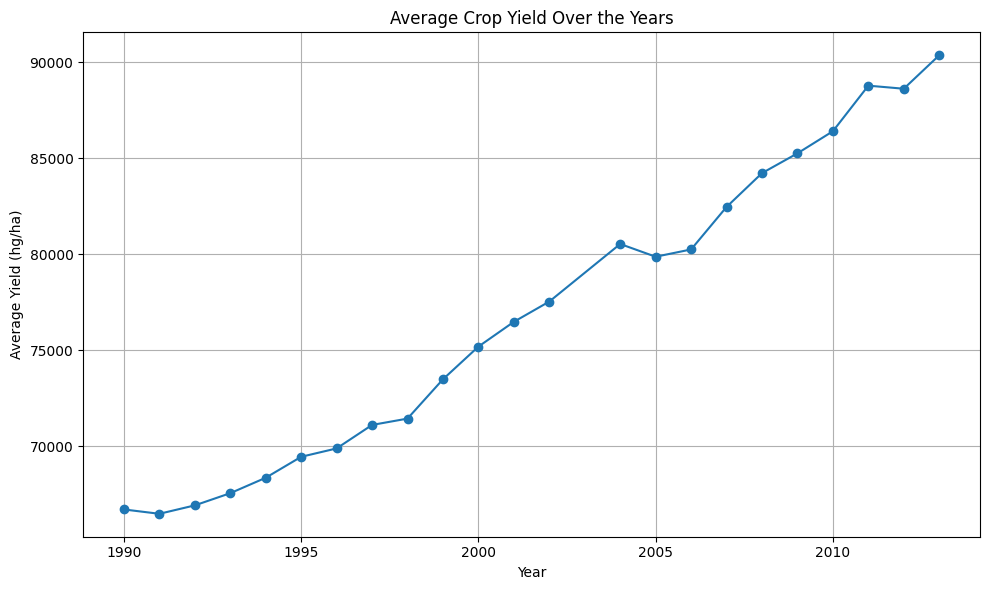

In [84]:
year_yield = df.groupby('Year')['hg/ha_yield'].mean()
plt.figure(figsize=(10, 6))
plt.plot(year_yield.index, year_yield.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Average Yield (hg/ha)')
plt.title('Average Crop Yield Over the Years')
plt.grid(True)
plt.tight_layout()
plt.show()

6.3 Rainfall vs Crop Yield

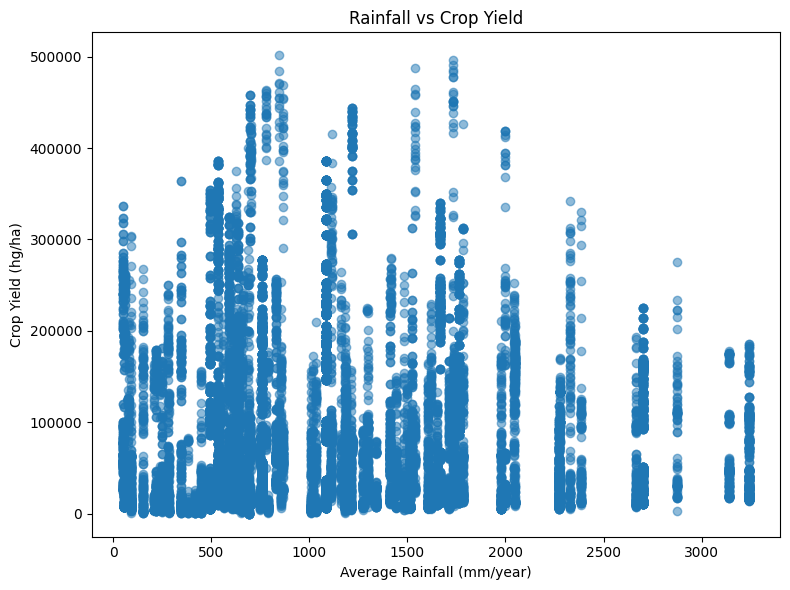

In [85]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df['average_rain_fall_mm_per_year'],
    df['hg/ha_yield'],
    alpha=0.5
)
plt.xlabel('Average Rainfall (mm/year)')
plt.ylabel('Crop Yield (hg/ha)')
plt.title('Rainfall vs Crop Yield')
plt.tight_layout()
plt.show()

6.4 Temperature vs Crop Yield

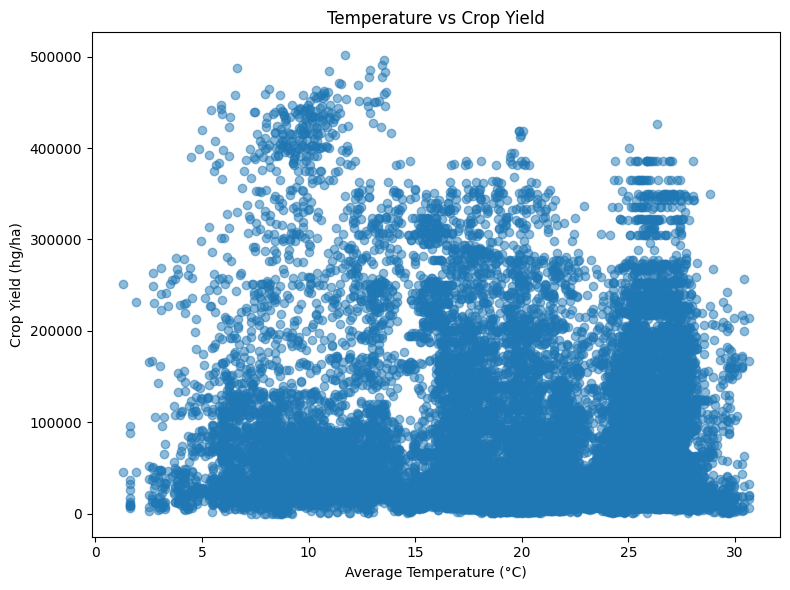

In [86]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df['avg_temp'],
    df['hg/ha_yield'],
    alpha=0.5
)
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Crop Yield (hg/ha)')
plt.title('Temperature vs Crop Yield')
plt.tight_layout()
plt.show()

6.5 Pesticides vs Crop Yield

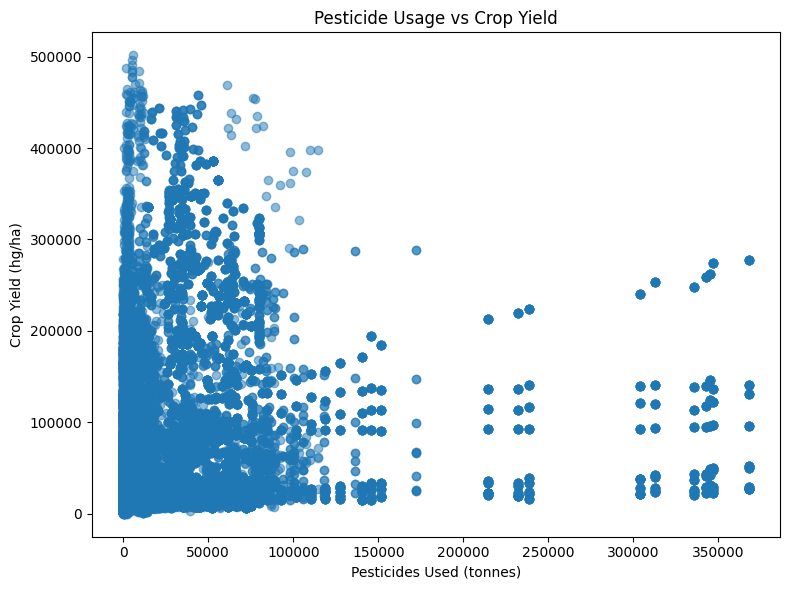

In [87]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df['pesticides_tonnes'],
    df['hg/ha_yield'],
    alpha=0.5
)
plt.xlabel('Pesticides Used (tonnes)')
plt.ylabel('Crop Yield (hg/ha)')
plt.title('Pesticide Usage vs Crop Yield')
plt.tight_layout()
plt.show()

6.6 Top 15 Areas by Average Yield

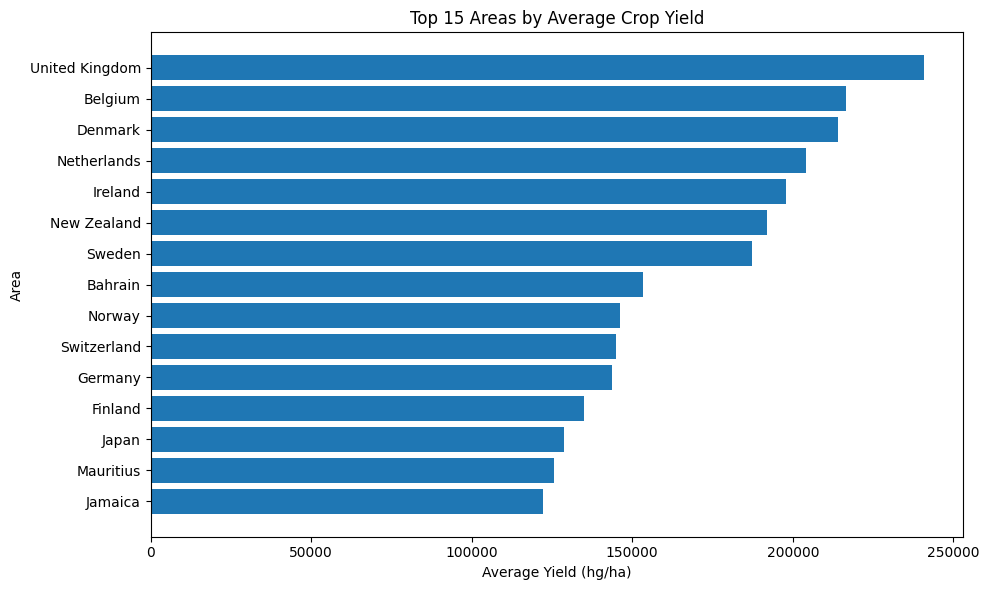

In [88]:
top_areas = (
    df.groupby('Area')['hg/ha_yield']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(10, 6))
plt.barh(top_areas.index[::-1], top_areas.values[::-1])
plt.xlabel('Average Yield (hg/ha)')
plt.ylabel('Area')
plt.title('Top 15 Areas by Average Crop Yield')
plt.tight_layout()
plt.show()

6.7 Correlation Analysis

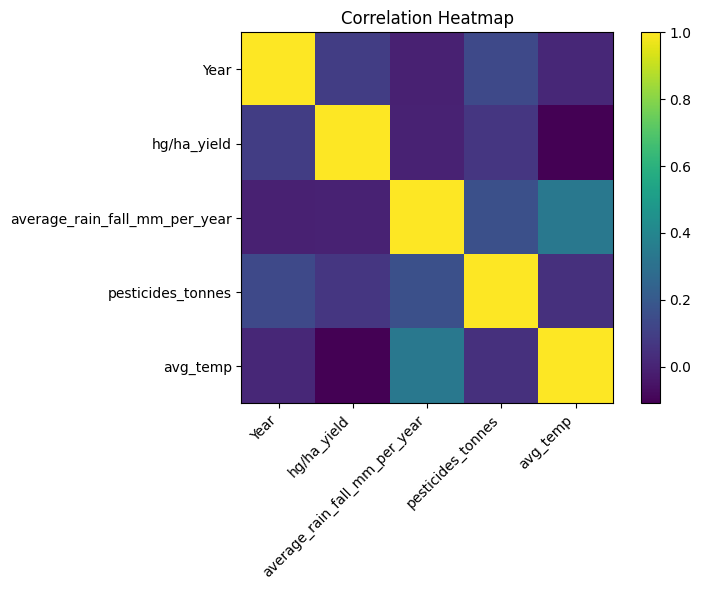

In [89]:
correlation = df[
    [
        'Year',
        'hg/ha_yield',
        'average_rain_fall_mm_per_year',
        'pesticides_tonnes',
        'avg_temp'
    ]
].corr()

plt.figure(figsize=(8, 6))
plt.imshow(correlation, interpolation='nearest')
plt.colorbar()
plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**STEP 7 — Feature Engineering**

Feature engineering is performed to create additional variables that may help the machine learning models capture useful relationships in the dataset.

Two additional features are created: the number of years since 1990 and an interaction feature between rainfall and average temperature.

7.1 Create Time Feature

In [90]:
df['years_since_1990'] = df['Year'] - 1990
print("Time-based feature created successfully!")
display(df[['Year', 'years_since_1990']].head(10))

Time-based feature created successfully!


,Year,years_since_1990
0,1990,0
1,1990,0
2,1990,0
3,1990,0
4,1990,0
5,1990,0
6,1991,1
7,1991,1
8,1991,1
9,1991,1


7.2 Create Rainfall × Temperature Feature

In [91]:
df['rainfall_temp_interaction'] = (
    df['average_rain_fall_mm_per_year'] * df['avg_temp']
)
print("Rainfall-temperature interaction feature created successfully!")
display(
    df[
        [
            'average_rain_fall_mm_per_year',
            'avg_temp',
            'rainfall_temp_interaction'
        ]
    ].head(10)
)

Rainfall-temperature interaction feature created successfully!


,average_rain_fall_mm_per_year,avg_temp,rainfall_temp_interaction
0,1485.0,16.37,24309.45
1,1485.0,16.37,24309.45
2,1485.0,16.37,24309.45
3,1485.0,16.37,24309.45
4,1485.0,16.37,24309.45
5,1485.0,16.37,24309.45
6,1485.0,15.36,22809.60
7,1485.0,15.36,22809.60
8,1485.0,15.36,22809.60
9,1485.0,15.36,22809.60


7.3 Check the New Dataset

In [92]:
print("Dataset Shape:", df.shape)
print("\nUpdated Columns:")
print(df.columns.tolist())

Dataset Shape: (25932, 9)

Updated Columns:
['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'years_since_1990', 'rainfall_temp_interaction']


**STEP 8 — Define Features and Target**

The input features and target variable are defined for the machine learning task.

The target variable is `hg/ha_yield`, which represents crop yield. The remaining relevant variables are used as input features for prediction.

In [93]:
X = df.drop('hg/ha_yield', axis=1)
y = df['hg/ha_yield']
print("Features:")
print(X.columns.tolist())
print("\nTarget:")
print(y.name)
print("\nTarget Shape:")
print(y.shape)

Features:
['Area', 'Item', 'Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'years_since_1990', 'rainfall_temp_interaction']

Target:
hg/ha_yield

Target Shape:
(25932,)


**STEP 9 — Identify Numerical and Categorical Features**

The input variables are separated into numerical and categorical features.

Numerical features contain continuous or numerical values, while categorical features represent groups such as geographical area and crop type. This separation is required to apply appropriate preprocessing techniques.

In [94]:
numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()
categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()
print("Numerical Features:")
print(numerical_features)
print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'years_since_1990', 'rainfall_temp_interaction']

Categorical Features:
['Area', 'Item']


**STEP 10 — Train-Test Split**

The dataset is divided into training and testing sets.

The training set is used to train the machine learning models, while the testing set is used to evaluate their performance on unseen data. An 80:20 split is used with a fixed random state to ensure reproducibility.

In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("\nTraining target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (20745, 8)
Testing data: (5187, 8)

Training target: (20745,)
Testing target: (5187,)


**STEP 11 — Preprocessing Pipeline**

Numerical and categorical features are processed using a ColumnTransformer.
Categorical variables are one-hot encoded, while numerical variables are
passed through the preprocessing pipeline.

In [96]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            'passthrough',
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)
print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [97]:
# Checking the number of features after preprocessing
preprocessor.fit(X_train)
feature_names = preprocessor.get_feature_names_out()
print("Number of features after preprocessing:", len(feature_names))
print("\nFirst 20 processed features:")
print(feature_names[:20])

Number of features after preprocessing: 117

First 20 processed features:
['num__Year' 'num__average_rain_fall_mm_per_year' 'num__pesticides_tonnes'
 'num__avg_temp' 'num__years_since_1990' 'num__rainfall_temp_interaction'
 'cat__Area_Albania' 'cat__Area_Algeria' 'cat__Area_Angola'
 'cat__Area_Argentina' 'cat__Area_Armenia' 'cat__Area_Australia'
 'cat__Area_Austria' 'cat__Area_Azerbaijan' 'cat__Area_Bahamas'
 'cat__Area_Bahrain' 'cat__Area_Bangladesh' 'cat__Area_Belarus'
 'cat__Area_Belgium' 'cat__Area_Botswana']


**STEP 12 — Model 1: Multiple Linear Regression**

Multiple Linear Regression is used as the first baseline model for predicting crop yield.

The model attempts to establish a linear relationship between the selected input features and crop yield. Its performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

In [98]:
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)
print("Multiple Linear Regression trained successfully!")

Multiple Linear Regression trained successfully!


In [99]:
# Evaluating Multiple Linear Regression

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)
print("Multiple Linear Regression Results")
print("-----------------------------------")
print(f"MAE  : {mae_linear:.2f}")
print(f"RMSE : {rmse_linear:.2f}")
print(f"R²   : {r2_linear:.4f}")

Multiple Linear Regression Results
-----------------------------------
MAE  : 31686.51
RMSE : 48164.70
R²   : 0.6799


**STEP 13 — Model 2: Polynomial Regression**

Polynomial Regression is used to capture non-linear relationships between the input features and crop yield.

Polynomial features are generated and a linear regression model is trained using these transformed features. The model is evaluated using MAE, RMSE, and R² score.

In [100]:
polynomial_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            PolynomialFeatures(
                degree=2,
                include_bias=False
            ),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

print("Polynomial preprocessing pipeline created!")

Polynomial preprocessing pipeline created!


In [101]:
# Training Polynomial Regression

polynomial_model = Pipeline(steps=[
    ('preprocessor', polynomial_preprocessor),
    ('regressor', LinearRegression())
])
polynomial_model.fit(X_train, y_train)
y_pred_poly = polynomial_model.predict(X_test)
print("Polynomial Regression trained successfully!")

Polynomial Regression trained successfully!


In [102]:
# Evaluating Polynomial Regression

mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)
print("Polynomial Regression Results")
print("-----------------------------")
print(f"MAE  : {mae_poly:.2f}")
print(f"RMSE : {rmse_poly:.2f}")
print(f"R²   : {r2_poly:.4f}")

Polynomial Regression Results
-----------------------------
MAE  : 63565.94
RMSE : 83296.17
R²   : 0.0427


**STEP 14 — Model 3: Decision Tree Regressor**

A Decision Tree Regressor is trained to predict crop yield by learning decision rules from the input features.
Decision trees can capture non-linear relationships and interactions between variables. The model performance is evaluated using MAE, RMSE, and R² score.

In [103]:
decision_tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(
        random_state=42
    ))
])

decision_tree_model.fit(X_train, y_train)
y_pred_tree = decision_tree_model.predict(X_test)
print("Decision Tree Regressor trained successfully!")

Decision Tree Regressor trained successfully!


In [104]:
# Evaluating Decision Tree

mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Regressor Results")
print("--------------------------------")
print(f"MAE  : {mae_tree:.2f}")
print(f"RMSE : {rmse_tree:.2f}")
print(f"R²   : {r2_tree:.4f}")

Decision Tree Regressor Results
--------------------------------
MAE  : 4327.63
RMSE : 13850.39
R²   : 0.9735


**STEP 15 — Model 4: Random Forest Regressor**

A Random Forest Regressor is developed as an ensemble learning model for crop yield prediction.

The Random Forest combines multiple decision trees to improve prediction performance and reduce the limitations of an individual decision tree.

The model is evaluated using MAE, RMSE, and R² score.

In [105]:
random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)
print("Random Forest Regressor trained successfully!")

Random Forest Regressor trained successfully!


In [106]:
# Evaluating Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Results")
print("--------------------------------")
print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Regressor Results
--------------------------------
MAE  : 4231.45
RMSE : 11036.94
R²   : 0.9832


**STEP 16 — Compare All 4 Models**

The performance of all four regression models is compared using MAE, RMSE, and R² score.

A lower MAE and RMSE indicate lower prediction error, while a higher R² score indicates better explanatory and predictive performance.

The model with the strongest overall performance is selected as the final model.

In [107]:
results = pd.DataFrame({
    'Model': [
        'Multiple Linear Regression',
        'Polynomial Regression (Degree 2)',
        'Decision Tree Regressor',
        'Random Forest Regressor'
    ],
    'MAE': [
        mae_linear,
        mae_poly,
        mae_tree,
        mae_rf
    ],
    'RMSE': [
        rmse_linear,
        rmse_poly,
        rmse_tree,
        rmse_rf
    ],
    'R2': [
        r2_linear,
        r2_poly,
        r2_tree,
        r2_rf
    ]
})

results = results.sort_values(
    by='R2',
    ascending=False
).reset_index(drop=True)

display(results)

,Model,MAE,RMSE,R2
0,Random Forest Regressor,4231.449084,11036.940213,0.983193
1,Decision Tree Regressor,4327.631772,13850.393393,0.973533
2,Multiple Linear Regression,31686.507782,48164.697735,0.679929
3,Polynomial Regression (Degree 2),63565.941073,83296.171726,0.042721


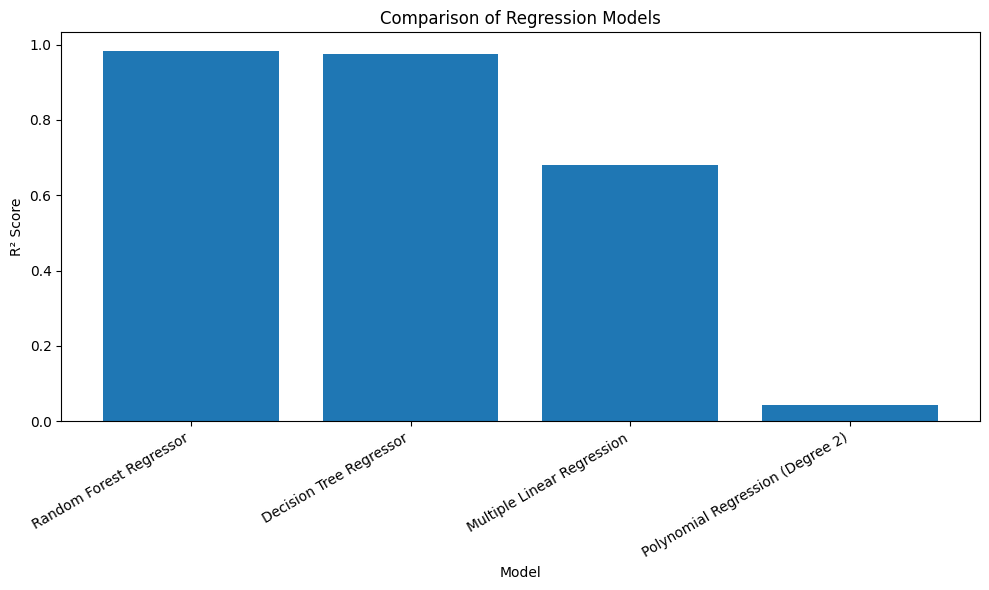

In [108]:
# Model R² comparison

plt.figure(figsize=(10, 6))
plt.bar(
    results['Model'],
    results['R2']
)
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('Comparison of Regression Models')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

The Random Forest Regressor achieved the highest R² score among the evaluated models, indicating that it provides the strongest predictive performance for this dataset.

**STEP 17 — Predicted vs Actual Plot**

The predicted crop yield values from the Random Forest Regressor are compared with the actual crop yield values using a scatter plot.

The diagonal reference line represents perfect predictions. Points closer to this line indicate predictions that are closer to the actual values.

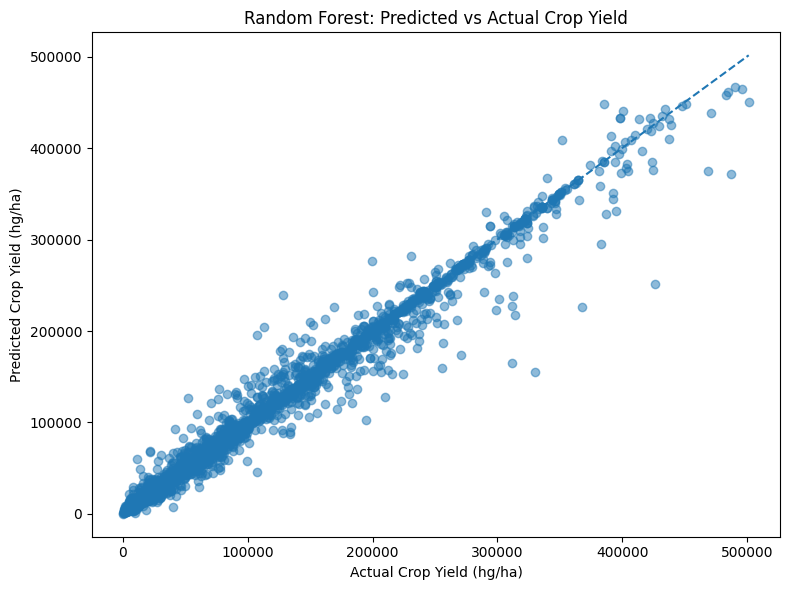

In [109]:
plt.figure(figsize=(8, 6))
plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)
min_value = min(y_test.min(), y_pred_rf.min())
max_value = max(y_test.max(), y_pred_rf.max())
plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)
plt.xlabel('Actual Crop Yield (hg/ha)')
plt.ylabel('Predicted Crop Yield (hg/ha)')
plt.title('Random Forest: Predicted vs Actual Crop Yield')
plt.tight_layout()
plt.show()

**STEP 18 — Feature Importance**

Feature importance is extracted from the trained Random Forest Regressor to identify which input features contribute most to crop yield prediction.

The importance scores provide an indication of the relative contribution of each processed feature to the model's predictions.

In [110]:
rf_preprocessor = random_forest_model.named_steps['preprocessor']
rf_regressor = random_forest_model.named_steps['regressor']
feature_names = rf_preprocessor.get_feature_names_out()
importances = rf_regressor.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)
display(feature_importance_df.head(20))

,Feature,Importance
0,cat__Item_Potatoes,0.372160
1,cat__Item_Cassava,0.091256
2,cat__Item_Sweet potatoes,0.085761
3,num__pesticides_tonnes,0.075032
4,cat__Area_India,0.057572
5,num__avg_temp,0.041340
6,num__average_rain_fall_mm_per_year,0.037995
7,num__rainfall_temp_interaction,0.037186
8,cat__Item_Yams,0.024424
9,num__Year,0.017449


18.1 — Clean Feature Names

In [111]:
clean_feature_names = []
for feature in feature_importance_df['Feature']:
    feature = feature.replace('num__', '')
    feature = feature.replace('cat__', '')
    feature = feature.replace('_', ' ')

    clean_feature_names.append(feature.title())

feature_importance_clean = pd.DataFrame({
    'Feature': clean_feature_names,
    'Importance': feature_importance_df['Importance']
})

display(feature_importance_clean.head(15))

,Feature,Importance
0,Item Potatoes,0.372160
1,Item Cassava,0.091256
2,Item Sweet Potatoes,0.085761
3,Pesticides Tonnes,0.075032
4,Area India,0.057572
5,Avg Temp,0.041340
6,Average Rain Fall Mm Per Year,0.037995
7,Rainfall Temp Interaction,0.037186
8,Item Yams,0.024424
9,Year,0.017449


The most important features are visualized to provide a clearer understanding of the variables that have the greatest influence on the Random Forest predictions.

18.2 — Feature Importance Chart

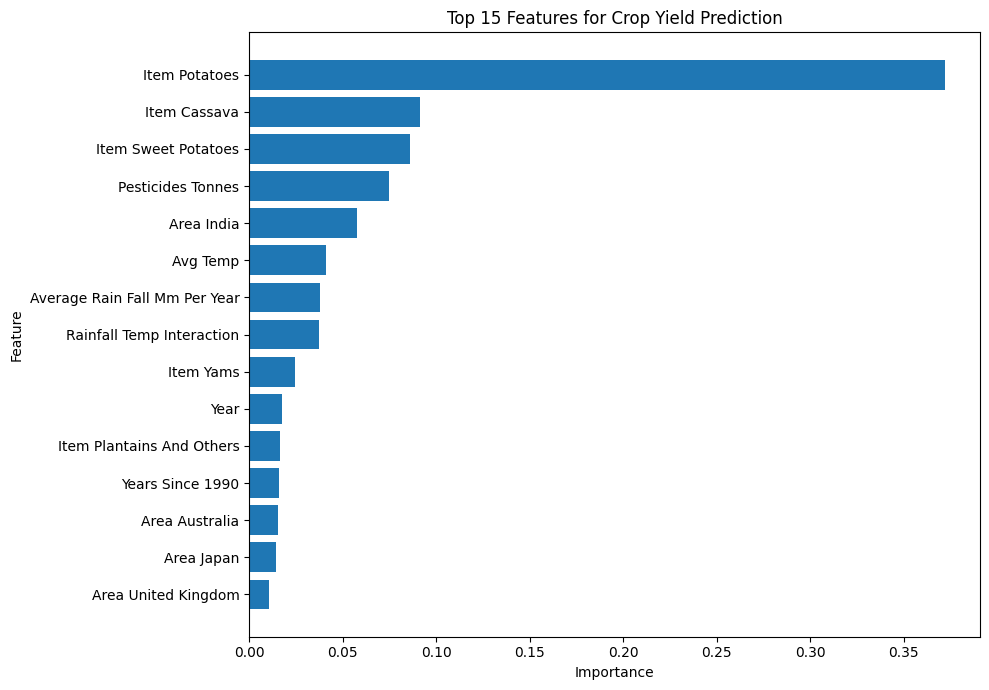

In [112]:
top_features = feature_importance_clean.head(15)
plt.figure(figsize=(10, 7))
plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Features for Crop Yield Prediction')
plt.tight_layout()
plt.show()

**STEP 19 — Save Results**

The model comparison results and feature importance results are saved as CSV files.

These files provide a reusable record of the model evaluation and feature importance analysis and can be included in the final project repository.

In [113]:
results.to_csv(
    'model_comparison.csv',
    index=False
)
print("Model comparison saved successfully!")

Model comparison saved successfully!


In [114]:
feature_importance_clean.to_csv(
    'feature_importance.csv',
    index=False
)
print("Feature importance saved successfully!")

Feature importance saved successfully!


**STEP 20 — Final Model Recommendation**

The four regression models are compared and the best-performing model is selected based on the R² score, while MAE and RMSE are also considered.

The Random Forest Regressor achieved the best overall performance with an R² score of 0.9832, MAE of 4231.45, and RMSE of 11036.94.

Therefore, the Random Forest Regressor is selected as the final model for crop yield prediction.

In [115]:
# Identifying  the best model

best_model = results.iloc[0]

print("Best Model:", best_model['Model'])
print("R²:", round(best_model['R2'], 4))
print("MAE:", round(best_model['MAE'], 2))
print("RMSE:", round(best_model['RMSE'], 2))

Best Model: Random Forest Regressor
R²: 0.9832
MAE: 4231.45
RMSE: 11036.94


### Final Model Performance

The Random Forest Regressor achieved the best overall performance among the four evaluated models.

- **R² Score:** 0.9832
- **MAE:** 4231.45
- **RMSE:** 11036.94

The high R² score indicates that the Random Forest Regressor provides strong predictive performance for crop yield prediction. Therefore, it is selected as the final model for this project.

**STEP 21 — Save the Best Model**

In [116]:
import joblib
joblib.dump(
    random_forest_model,
    'random_forest_crop_yield_model.pkl'
)
print("Random Forest model saved successfully!")

Random Forest model saved successfully!


**STEP 22 — Test the Saved Model**

In [117]:
loaded_model = joblib.load(
    'random_forest_crop_yield_model.pkl'
)
test_predictions = loaded_model.predict(X_test)
print("Saved model loaded successfully!")
print("Number of predictions:", len(test_predictions))

Saved model loaded successfully!
Number of predictions: 5187


**STEP 23 — Sample Prediction**

In [118]:
sample = X_test.iloc[[0]]
actual_yield = y_test.iloc[0]
predicted_yield = loaded_model.predict(sample)[0]
print("Sample Input:")
display(sample)
print("\nActual Crop Yield:", actual_yield)
print("Predicted Crop Yield:", round(predicted_yield, 2))

Sample Input:


,Area,Item,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,years_since_1990,rainfall_temp_interaction
345,Angola,Cassava,2010,1010.0,40.0,24.44,20,24684.4



Actual Crop Yield: 155782
Predicted Crop Yield: 110312.35


**STEP 24 — Prediction Error Analysis**

In [119]:
errors = y_test - y_pred_rf
print("Mean Error:", round(errors.mean(), 2))
print("Minimum Error:", round(errors.min(), 2))
print("Maximum Error:", round(errors.max(), 2))

Mean Error: 400.26
Minimum Error: -111556.57
Maximum Error: 175002.95


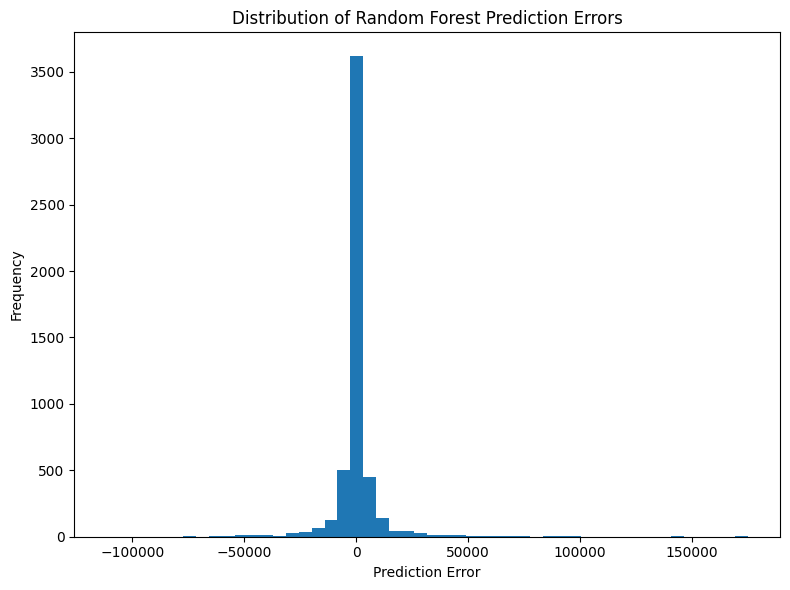

In [120]:
plt.figure(figsize=(8, 6))
plt.hist(errors, bins=50)
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Random Forest Prediction Errors')
plt.tight_layout()
plt.show()

# **Final Model Summary**

## Final Model Performance

Four regression algorithms were evaluated for crop yield prediction:

1. Multiple Linear Regression
2. Polynomial Regression
3. Decision Tree Regressor
4. Random Forest Regressor

Among these models, the Random Forest Regressor achieved the best performance.

### Final Performance

- **R² Score:** 0.9832
- **MAE:** 4231.45
- **RMSE:** 11036.94

The Random Forest Regressor was therefore selected as the final model for crop yield prediction.

In [121]:
# Saving all four trained Theme 8 models

import joblib
joblib.dump(linear_model, 'linear_regression.pkl')
joblib.dump(polynomial_model, 'polynomial_regression.pkl')
joblib.dump(decision_tree_model, 'decision_tree.pkl')
joblib.dump(random_forest_model, 'random_forest.pkl')
print("All four Crop Yield models saved successfully!")

All four Crop Yield models saved successfully!


In [122]:
linear_loaded = joblib.load('linear_regression.pkl')
polynomial_loaded = joblib.load('polynomial_regression.pkl')
tree_loaded = joblib.load('decision_tree.pkl')
rf_loaded = joblib.load('random_forest.pkl')
print("All four Crop Yield models loaded successfully!")

All four Crop Yield models loaded successfully!


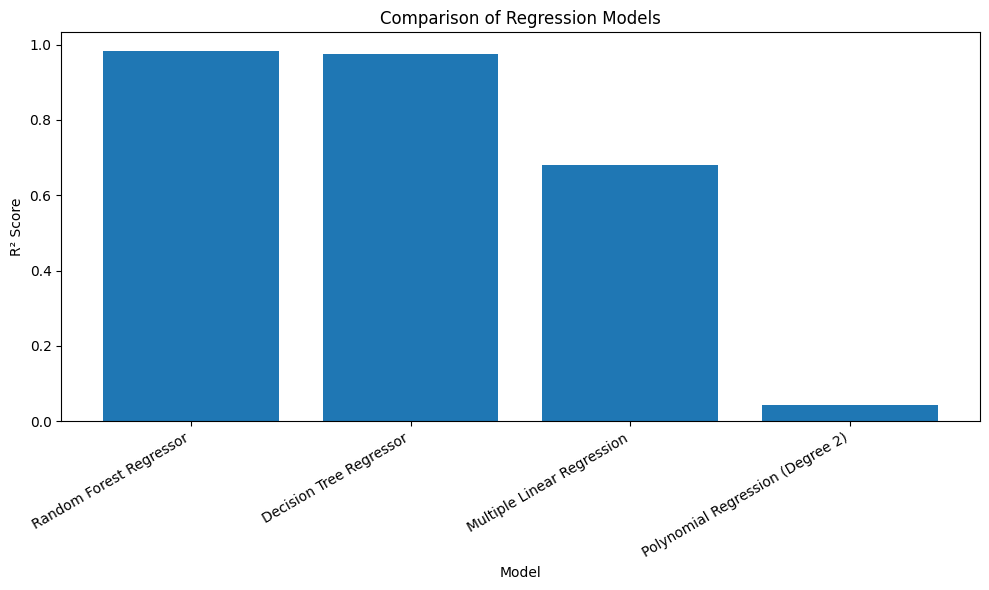

Model comparison chart saved successfully!


In [123]:
# Save Model Comparison Chart

plt.figure(figsize=(10, 6))
plt.bar(
    results['Model'],
    results['R2']
)
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('Comparison of Regression Models')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('comparison_table.png', dpi=300, bbox_inches='tight')
plt.show()
print("Model comparison chart saved successfully!")

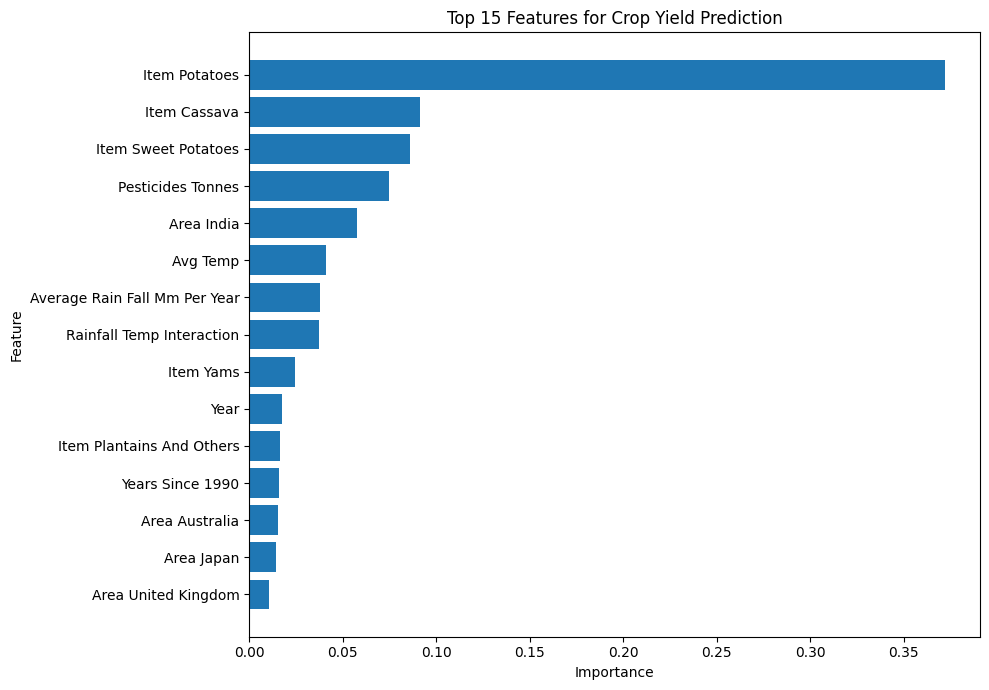

Feature importance chart saved successfully!


In [124]:
# Saving Feature Importance Chart

top_features = feature_importance_clean.head(15)
plt.figure(figsize=(10, 7))
plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Features for Crop Yield Prediction')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Feature importance chart saved successfully!")

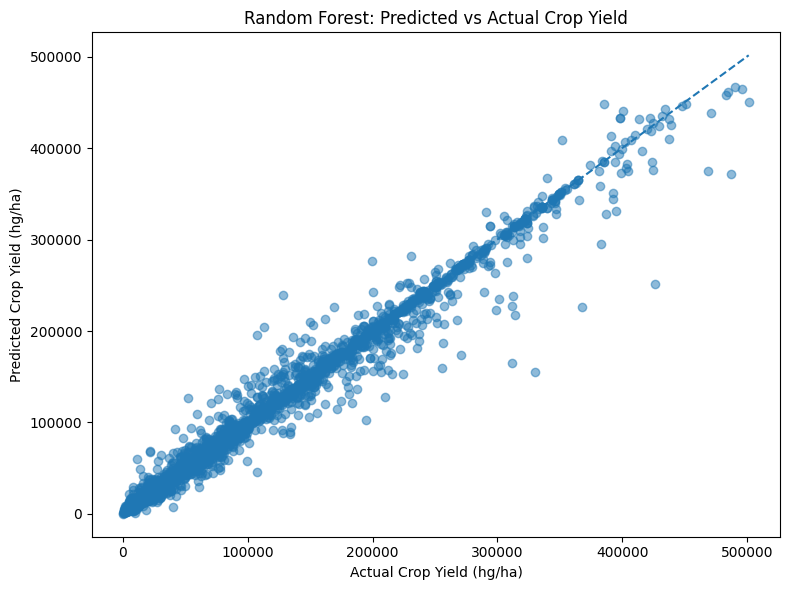

Prediction plot saved successfully!


In [125]:
# Saving Predicted vs Actual Plot
plt.figure(figsize=(8, 6))
plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)
min_value = min(y_test.min(), y_pred_rf.min())
max_value = max(y_test.max(), y_pred_rf.max())
plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)
plt.xlabel('Actual Crop Yield (hg/ha)')
plt.ylabel('Predicted Crop Yield (hg/ha)')
plt.title('Random Forest: Predicted vs Actual Crop Yield')
plt.tight_layout()
plt.savefig('prediction_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Prediction plot saved successfully!")

## **Conclusion**

- This project developed a machine learning-based system for predicting agricultural crop yield using historical agricultural, environmental, and climatic data.

- The dataset contains information about crop type, geographical area, year, rainfall, pesticide usage, temperature, and crop yield.

- Four regression models were trained and evaluated. The Random Forest Regressor produced the best results with an R² score of 0.9832, MAE of 4231.45, and RMSE of 11036.94.

 - The results demonstrate that machine learning can effectively model relationships between agricultural and environmental factors and crop yield.

- The developed model can potentially support agricultural planning, yield estimation, and data-driven decision making.